The goal of this notebook is to figure out how to calculate the infall times of subhalos onto "massive progenitors" and onto the "main host"
Main goals:
* t_infall_anything_bigger = time or snapshot when the subhalo under scrutiny falls into *any* more massive object (massive progenitor or main host). This would be "first_infall_snap" in the Symphony halo-level data (don't know where exactly yet).
* t_infall_main_host = time when the subhalo under scrutiny falls into *specifically* the main host. This would be "merger_snap" in the Symphony halo-level data, in the "hist" (time-independent) data.
* t_disrupt = time when the subhalo under scrutiny falls below the density required for ROCKSTAR to designate it a subhalo (300 particles)

Using these:
* Create probability density functions (basically histograms) where the infall times are sorted into time bins, allowing us to see if/when the distribution of infall times is peaked and how it behaves across different mass ranges. It would be good to make one version that is not normalized to host formation time, and another that is.
* Create a plot using an autocorrelation function to measure how correlated the infall times of the "massive progenitor" are with the other subhalos (both field and associated I assume? This is the one I'm less clear on). It may also be useful to have a version that shows this effect but for different lines of sight. Autocorrelation should be giving a characteristic time interval for subhalo infalls.
* Calculate the "preprocessed fraction," in other words the number of subhalos that fall onto something else before falling onto the MW, divided by the total number
* Make a plot comparing the location/slope of the SHMF (before and after a particular massive infall), and the other side showing the change in the subhalo count of the massive infalls (GSE, LMC). Would be good to put side-by-side.
* Cross-correlation function (?)

In [1]:
## packages and globals

import symlib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
from matplotlib import colormaps
import matplotlib.colors as mcolors
from symlib.util import DEFAULT_HALO_NAMES

In [29]:
## GLOBALS
base_dir = "C:/Users/steph/Symphony"
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]

#suite_list = ["SymphonyLMC", "SymphonyMilkyWay"]
#colors = ["tab:purple", "tab:blue"]

In [34]:
## one function to read in all the data
def load_infall_data(base_dir, suite_list):

    ## creating a dictionary to store all the values
    suite_data = {}

    for suite_index, suite in enumerate(suite_list):

        print(f"\nLoading suite: {suite}")

        halo_names = DEFAULT_HALO_NAMES[suite]

        ## get global scale factors for this suite
        sim_dir0 = symlib.get_host_directory(base_dir, suite, 0)
        scale_factors = symlib.scale_factors(sim_dir0)
        nbins_suite = len(scale_factors)

        ## storage
        raw_counts_all = []
        hosts = []

        for halo_index, halo_name in enumerate(halo_names):

            print(f"  Halo {halo_index+1}/{len(halo_names)}: {halo_name}", end="\r", flush=True)

            sim_dir = symlib.get_host_directory(base_dir, suite, halo_name)
            h, hist = symlib.read_subhalos(sim_dir)

            ## subhalo infall data (getting infall snapshots, etc)
            merger_snap = hist["merger_snap"]
            valid = merger_snap > 0
            valid_snap = merger_snap[valid].astype(int)

            ## infall scale factors and corresponding subhalo masses
            a_infall = scale_factors[valid_snap]
            mpeak = hist["mpeak"][valid]

            ## getting the snapshot and scale factor corresponding to the first time the host crosses the 50% mass point
            mvir = h["mvir"][0, :]
            peak_mass = np.max(mvir)
            cross = np.where(mvir >= 0.5 * peak_mass)[0]
            
            if len(cross) == 0:
                a50 = np.nan
            else:
                a50_snap = cross[0]
                a50 = scale_factors[a50_snap]

            # avoid bad normalization
            if not np.isfinite(a50) or a50 <= 0:
                a_infall_norm = np.full_like(a_infall, np.nan)
            else:
                a_infall_norm = a_infall / a50

            ## storing per-host structured data
            host_data = {"a_infall": a_infall, "a_infall_norm": a_infall_norm, 
                         "mpeak": mpeak, "host_mass": peak_mass, "a50": a50}

            hosts.append(host_data)

            ## counts per snapshot
            counts = np.zeros(nbins_suite)
            unique_snaps, snap_counts = np.unique(valid_snap, return_counts = True)
            counts[unique_snaps] = snap_counts
            raw_counts_all.append(counts)

        ## getting final dictionary of values for the suite
        suite_data[suite] = {"scale_factors": scale_factors, "raw_counts": np.array(raw_counts_all), "hosts": hosts}
        
        print(f"Finished suite: {suite} ({len(hosts)} halos)")

    return suite_data

In [35]:
## load data once
suite_data = load_infall_data(base_dir, suite_list)


Loading suite: SymphonyLMC
Finished suite: SymphonyLMC (39 halos)

Loading suite: SymphonyMilkyWay
Finished suite: SymphonyMilkyWay (45 halos)

Loading suite: SymphonyGroup
Finished suite: SymphonyGroup (49 halos)

Loading suite: SymphonyLCluster
Finished suite: SymphonyLCluster (33 halos)

Loading suite: SymphonyCluster
Finished suite: SymphonyCluster (81 halos)


In [36]:
## functions to plot the raw, un-normalized data

def compute_raw_counts_stats(raw_counts):
    
    mean = np.mean(raw_counts, axis = 0)
    p16_raw = np.percentile(raw_counts, 16, axis = 0)
    p84_raw = np.percentile(raw_counts, 84, axis = 0)

    return mean, p16_raw, p84_raw

def plot_raw_counts(ax, scale_factors, raw_counts, color, label = None, fill = False):

    mean, p16_raw, p84_raw = compute_raw_counts_stats(raw_counts)
    
    ax.plot(scale_factors, mean, color = color, lw = 2)
    
    if fill:
        ax.fill_between(scale_factors, p16_raw, p84_raw, color = color, alpha = 0.25)


## PDF HELPER FUNCTIONS
def compute_pdf(values, grid):

    values = values[np.isfinite(values)]
    
    if len(values) == 0:
        return np.zeros_like(grid)

    hist, edges = np.histogram(values, bins = grid, density = True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    return centers, hist


def compute_pdf_stats_hosts(hosts, key, grid, mask_fn = None):

    pdf_stack = []
    centers = None

    for h in hosts:

        values = h[key]

        # optional filtering (e.g. by mass)
        if mask_fn is not None:
            mask = mask_fn(h)
            values = values[mask]

        if len(values) == 0:
            continue

        c, pdf = compute_pdf(values, grid)
        centers = c
        pdf_stack.append(pdf)

    pdf_stack = np.array(pdf_stack)

    if len(pdf_stack) == 0:
        return centers, None, None, None

    mean = np.mean(pdf_stack, axis=0)
    p16  = np.percentile(pdf_stack, 16, axis=0)
    p84  = np.percentile(pdf_stack, 84, axis=0)

    return centers, mean, p16, p84


def plot_pdf_hosts(ax, hosts, key, grid, color, mask_fn = None, label = None, fill = False):

    centers, mean, p16, p84 = compute_pdf_stats_hosts(hosts, key, grid, mask_fn)

    if mean is None:
        return

    ax.plot(centers, mean, color = color, lw = 2, label = label)

    if fill:
        ax.fill_between(centers, p16, p84, color = color, alpha = 0.25)


## CDF HELPER FUNCTIONS
def compute_cdf(values, grid):

    values = np.sort(values)
    if len(values) == 0:
        return np.zeros_like(grid)

    cdf = np.arange(1, len(values) + 1) / len(values)
    return np.interp(grid, values, cdf, left = 0, right = 1)


def compute_cdf_stats_hosts(hosts, key, grid, mask_fn = None):

    cdf_stack = []

    for h in hosts:

        values = h[key]

        if mask_fn is not None:
            mask = mask_fn(h)
            values = values[mask]

        values = values[np.isfinite(values)]
        if len(values) == 0:
            continue

        cdf_stack.append(compute_cdf(values, grid))

    cdf_stack = np.array(cdf_stack)

    if len(cdf_stack) == 0:
        return None, None, None

    mean = np.mean(cdf_stack, axis = 0)
    p16  = np.percentile(cdf_stack, 16, axis = 0)
    p84  = np.percentile(cdf_stack, 84, axis = 0)

    return mean, p16, p84

## function to plot the CDFs
def plot_cdf_hosts(ax, hosts, key, grid, color, mask_fn = None, label = None, fill = False):

    mean, p16, p84 = compute_cdf_stats_hosts(hosts, key, grid, mask_fn)

    if mean is None:
        return

    ax.plot(grid, mean, color = color, lw = 2, label = label)
    
    if fill:
        ax.fill_between(grid, p16, p84, color = color, alpha = 0.25)

In [48]:
## INFALL FIGURE WITH PDFs AND CDFs
def make_infall_figure_full(suite_data, suite_list, colors):

    nrows = 5
    ncols = len(suite_list)

    fig, ax = plt.subplots(nrows = nrows, ncols = ncols, figsize = (6 * ncols, 4 * nrows), constrained_layout = True, squeeze = False)

    ## GRIDS FOR CDF
    a_grid_raw = np.linspace(0, 1, 100)
    a_grid_norm = np.linspace(0, 3, 100)

    ## BINS FOR PDF
    a_bins_raw = np.linspace(0, 1, 40)
    a_bins_norm = np.linspace(0, 3, 40)

    for i, suite in enumerate(suite_list):

        data = suite_data[suite]
        color = colors[i]

        scale_factors = data["scale_factors"]
        raw_counts = data["raw_counts"]
        hosts = data["hosts"]

        ## RAW COUNTS
        plot_raw_counts(ax[0, i], data["scale_factors"], data["raw_counts"], color = color, fill = True)

        ## RAW PDF
        plot_pdf_hosts(ax[1, i], hosts, key = "a_infall", grid = a_bins_raw, color = color, fill = True)

        ## RAW CDF
        plot_cdf_hosts(ax[2, i], hosts, key = "a_infall", grid = a_grid_raw, color = color, fill = True)

        ## NORMALIZED PDF
        plot_pdf_hosts(ax[3, i], hosts, key = "a_infall_norm", grid = a_bins_norm, color = color, fill = True)

        ## NORMALIZED CDF
        plot_cdf_hosts(ax[4, i], hosts, key = "a_infall_norm", grid = a_grid_norm, color = color, fill = True)


        ## x labels
        ax[0, i].set_xlim(0, 1)
        ax[1, i].set_xlim(0, 1)
        ax[2, i].set_xlim(0, 1)
        ax[3, i].set_xlim(0, 3)
        ax[4, i].set_xlim(0, 3)

        ax[0, i].set_title(suite, fontsize = 18)

    ## y labels
    ax[0, 0].set_ylabel("Counts per Snapshot", fontsize = 14)
    ax[1, 0].set_ylabel("PDF ($a_{\\rm infall}$)", fontsize = 14)
    ax[2, 0].set_ylabel("CDF ($a_{\\rm infall}$)", fontsize = 14)
    ax[3, 0].set_ylabel("PDF ($a_{\\rm infall}/a_{50}$)", fontsize = 14)
    ax[4, 0].set_ylabel("CDF ($a_{\\rm infall}/a_{50}$)", fontsize = 14)

    for j in range(ncols):
        ax[0, j].set_xlabel("Scale Factor $a(t)$", fontsize = 14)
        ax[1, j].set_xlabel("Scale Factor $a(t)$", fontsize = 14)
        ax[2, j].set_xlabel("Scale Factor $a(t)$", fontsize = 14)
        ax[3, j].set_xlabel(r"$a_{\rm infall} / a_{50}$", fontsize = 14)
        ax[4, j].set_xlabel(r"$a_{\rm infall} / a_{50}$", fontsize = 14)

    return fig, ax

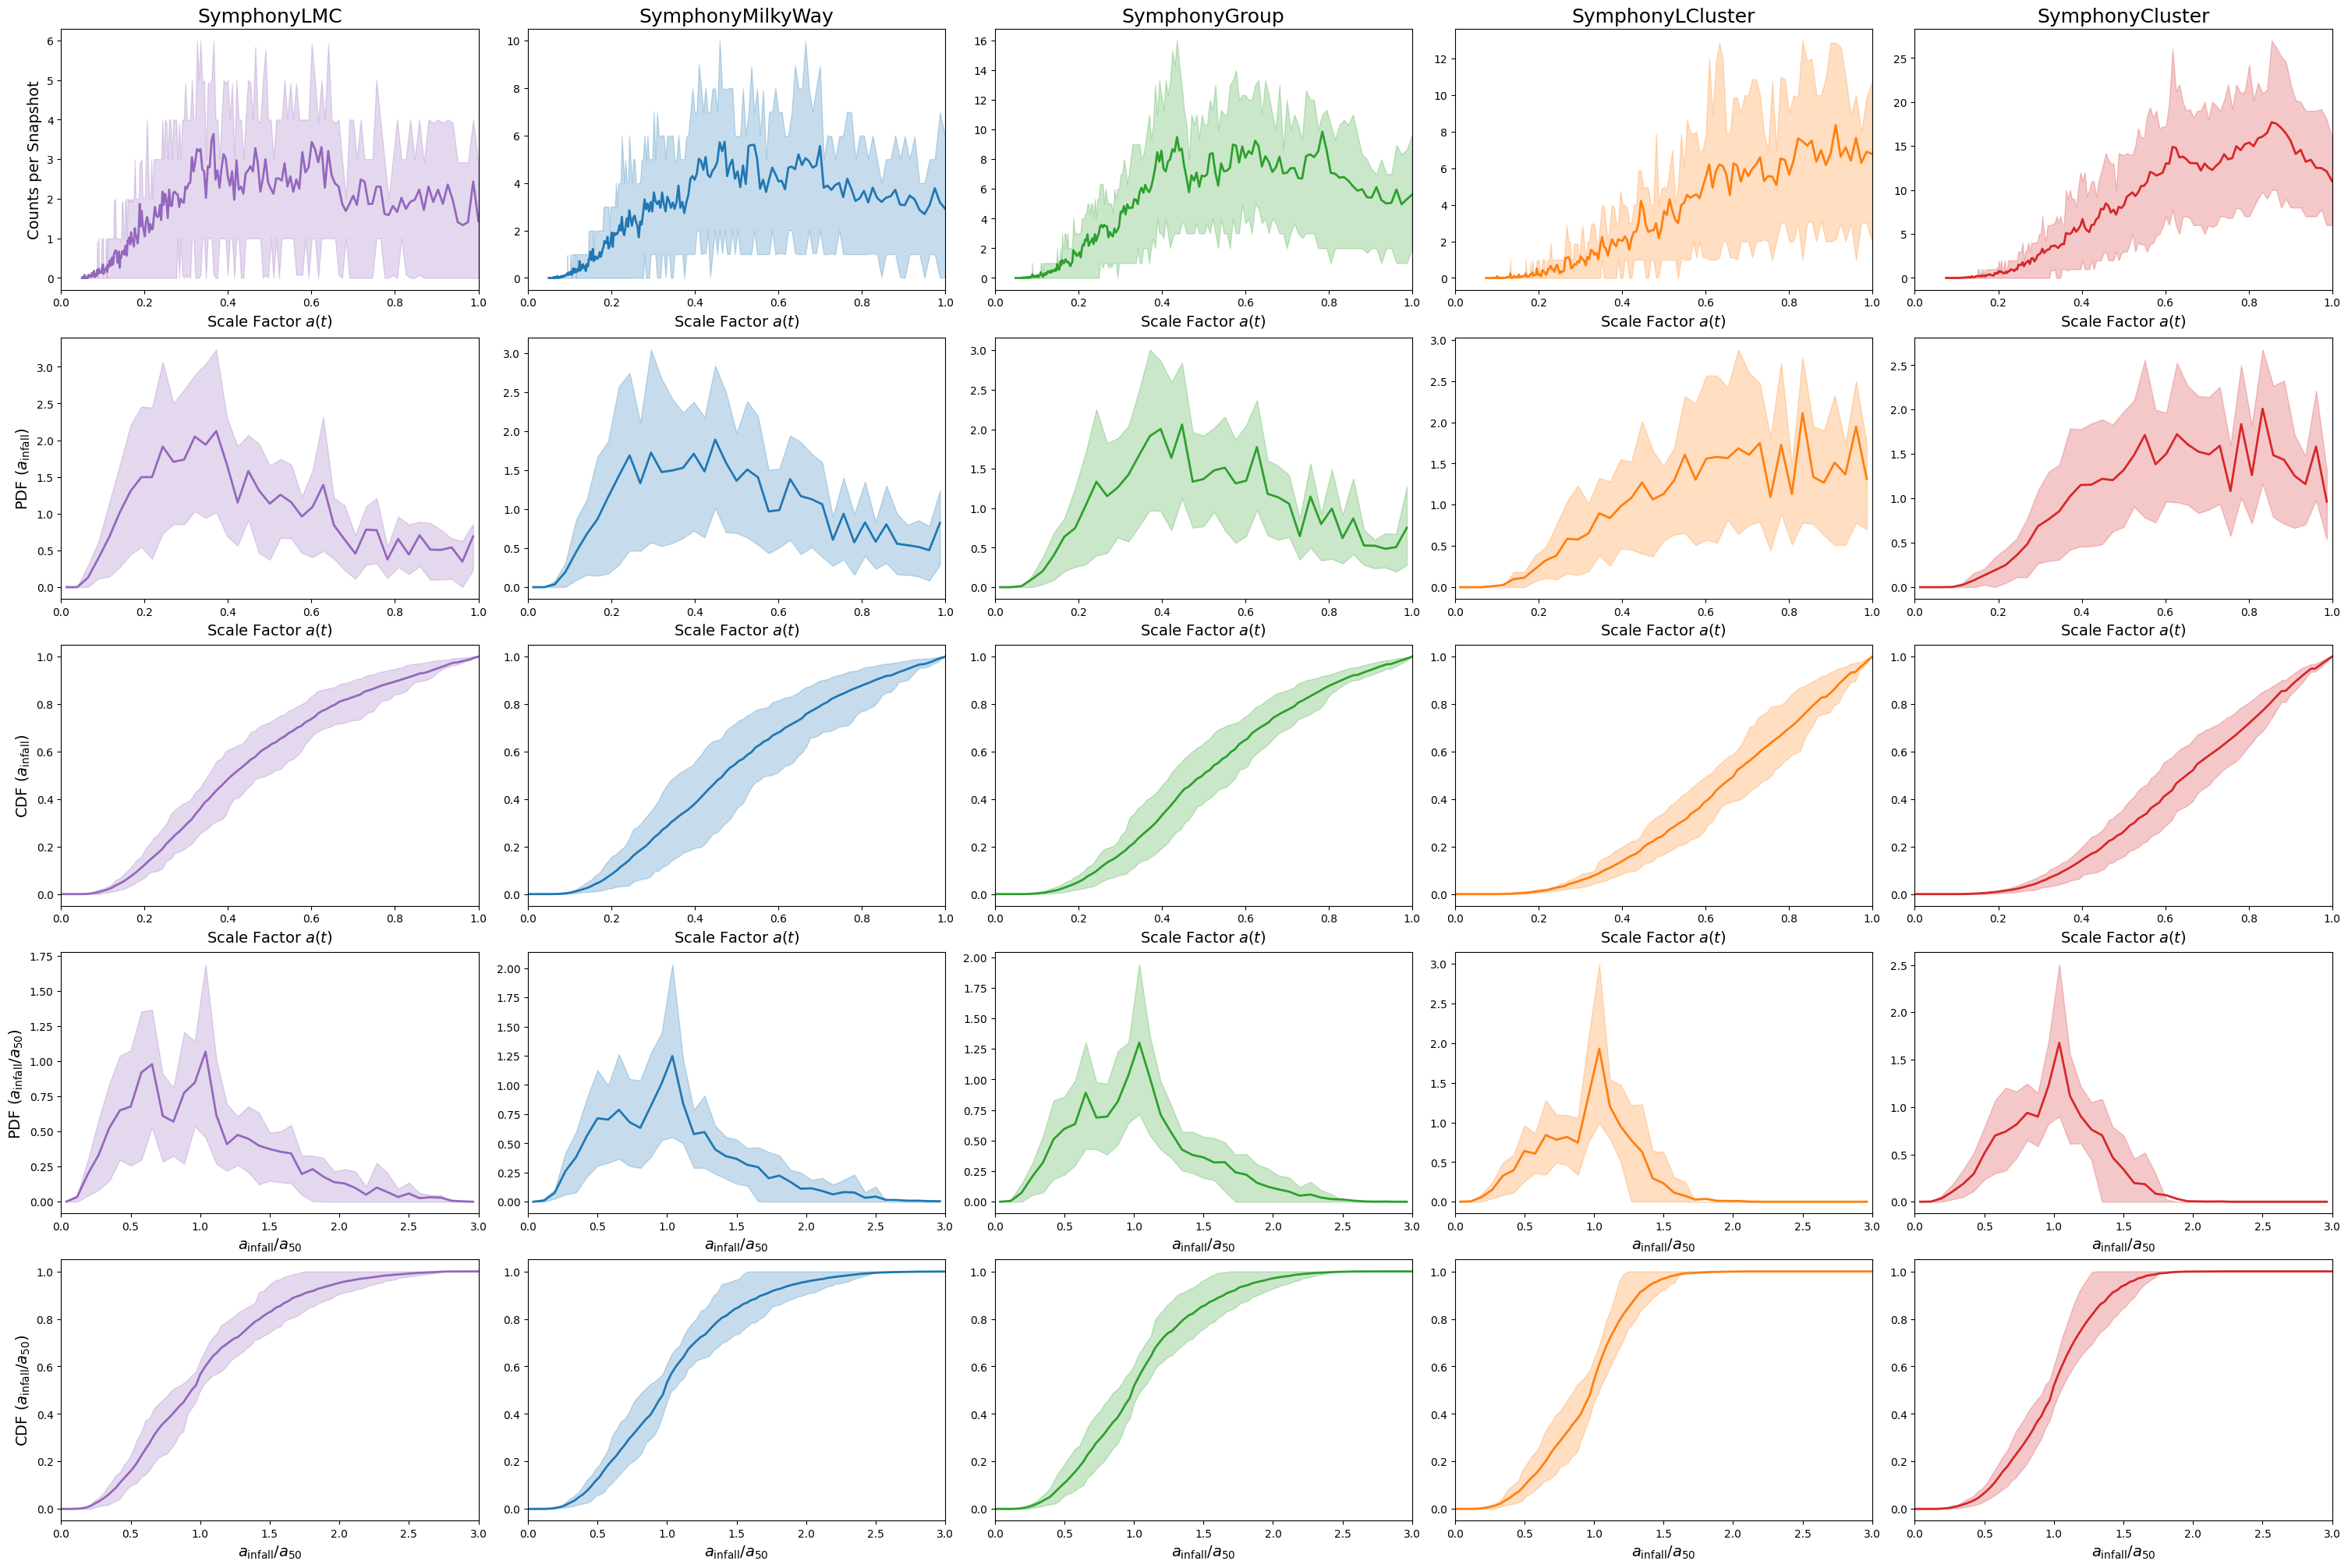

In [50]:
## make plotting adjustments as needed
fig, ax = make_infall_figure_full(suite_data, suite_list, colors)

plt.savefig("infalltimes_CDF_and_PDF.png")
plt.show()